In [ ]:
# Install if you need to have turnable 3D plots
!pip install ipympl

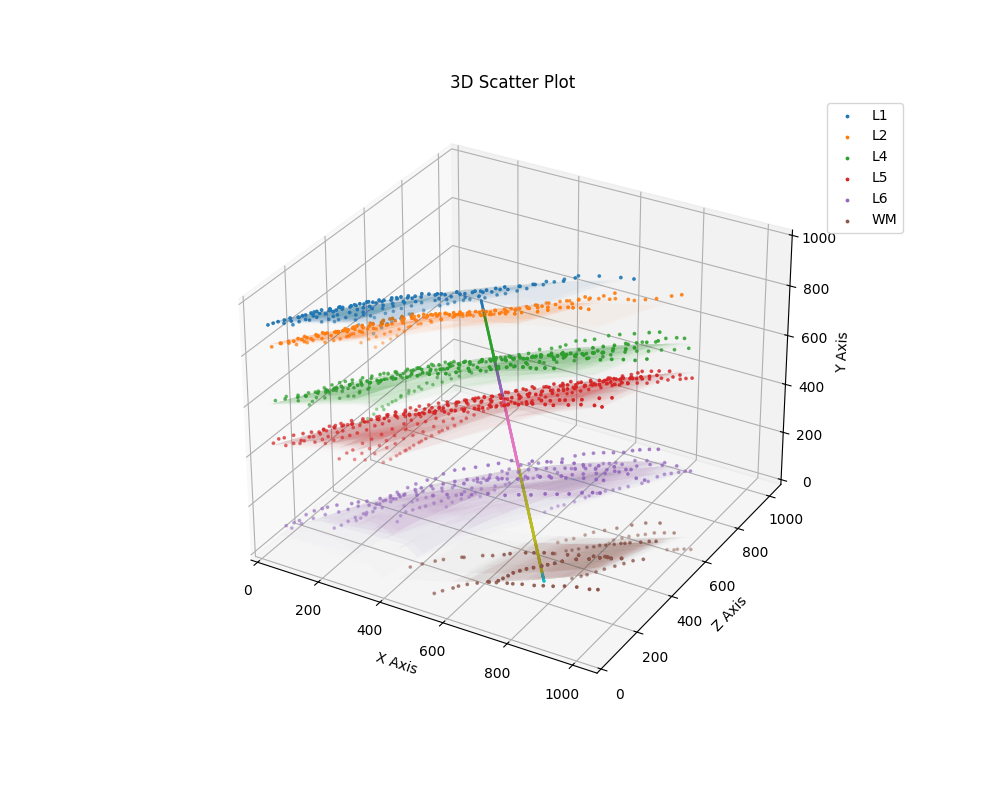

In [ ]:
%matplotlib widget

import os
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import curve_fit
import numpy as np

# Function to read CSV files and return a DataFrame
def read_csv_file(file_path):
    return pd.read_csv(file_path)

# Function to plot 3D scatter plot
def plot_3d_scatter(df, label, color, point_size):
    ax.scatter(df.iloc[:, 0], df.iloc[:, 2], df.iloc[:, 1], label=label, color=color, s=point_size)

# Define mathematical function for curve fitting 
def func(xz, a, b, c, d, e, f): 
    x, z= xz
    return  a + b*x + c*z + d*x**2 + e*z**2 + f*x*z   # Fits layers as parabolic surfaces defined as y= a + bx + cz + dx2 + ez2 +fxz

# Directory containing CSV files with annotated layers: individual directories for each image
folder_path = 'C:/Users/Sriram Sudarsanam/Desktop/LayerBorders/P7/SS324_P7_B1_I1_Borders'

layers = {}

# Create a colormap for distinguishing different datasets
cmap = plt.get_cmap('tab10')

# Initialize the figure and 3D axis
fig = plt.figure(figsize=(10, 8))  # Adjust figsize here
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(0,1052)
ax.set_ylim(0,1052)
ax.set_zlim(0,1000)

# Iterate over each boundary annotation csv filename to identify which border the file defines
for i, filename in enumerate(os.listdir(folder_path)):
    if filename.endswith('.csv'):
        label = filename.split('.')[0]  # Extract label from filename
        if label.split('_')[-2] == 'ia': #Last two characters ia-> Pia-> defies L1 top
            layer_name = 'L1'
        elif label.split('_')[-2] == 'WM':
            layer_name = 'WM'
        else: layer_name = label.split('_')[-2] #Last two characters of filename will define layer as 2, 4, 5 or 6
        
        color = cmap(i)  # Get a color from the colormap
        df = read_csv_file(os.path.join(folder_path, filename))  # Read CSV file
        
        # Plot 3D scatter plot of all points used to define the layers
        plot_3d_scatter(df, layer_name, color, point_size=3)
        
        
        # Use the curve fiting function to define the surface equation for each layer boundary from annotated points
        #For a small number of images, the tilt made it inaccurate to use y-coordinate to define layers. There, a modified version of this code 
        # where layer boundaries were estimated using x coordinate as a function of y and z was used instead 
        popt, pcov = curve_fit(func, (df['x'], df['z']), df['y']) 
        layers[layer_name] = popt
        
        X, Z = np.meshgrid(df['x'], df['z']) 
        Y = func((X, Z), *popt) 
        #3d polot of fitted surface overlaid on annotated points
        ax.plot_surface(X, Z, Y, color=color, alpha=0.01, shade= False)

#Load swc data corresodning to individual neuron in the image
data_df = pd.DataFrame(np.loadtxt("C:/Users/Sriram Sudarsanam/Desktop/LayerBorders/AllVectors_20241207/SS324_P7_B1_I1_N1_vector.txt"))
# Add a new column for layer identity
data_df['layer'] = [None]*len(data_df)

layers = dict(sorted(layers.items()))
#For each y-coordinate in swc, check which layer boundary it lies immediately above and use this to assign the right layer. i.e above WM-> L6, above L6 border-> L5 and so on
for idx, d in data_df.iterrows():
    pred_y=[] #New array to store the difference between y-coordinate of swc point and the predicted y-corrdinate of each layer for x,z corrspondign to the point
    y=d[3]
    for layer_name, popt in layers.items():
        
        #a + b*x + c*z + d*x**2 + e*z**2 + f*x*z
        pred_y.append(y-(popt[0] + popt[1]*d[2] + popt[2]*d[4] + popt[3]*d[2]*d[2] + popt[4]*d[4]*d[4] + popt[5]*d[2]*d[4]) )
    
    # Get indices of elements greater than 0
    indices_greater_than_zero = [i for i, val in enumerate(pred_y) if val > 0]
    # Find the index of the smallest positive element, use to assign value to layer columns
    # (indices go from 0 (pia), 1 (L2/3 top boundary), 2 (L4 top) 3 (L5 top) 4 (L6 top) 5 (WM top))
    if indices_greater_than_zero:
        data_df.at[idx,'layer'] = min(indices_greater_than_zero) + 1 # value = 2-> L1, 3-> L2/3, 4-> L4, 5-> L5, 6-> L6 
    else:
        data_df.at[idx,'layer'] = 7 # 7 -> WM

# Save the DataFrame to a new annoated .txt file which has the layer identity column in addition to the rest of the .swc file columns
data_df.to_csv('C:/Users/Sriram Sudarsanam/Desktop/LayerBorders/AllVectors_20241207/SS324_P7_B1_I1_N1_vector_Annotated.txt', sep='\t', index=False, header= False)

#Overlay layer annotated neuron reconstruction plot on boundary plot
ax.scatter(data_df[2], data_df[4], data_df[3], c=data_df['layer'], cmap='tab10', s=1)
    
# Set labels and title
ax.set_xlabel('X Axis')
ax.set_ylabel('Z Axis')
ax.set_zlabel('Y Axis')
plt.title('3D Scatter Plot')

# Show legend and move it to the far right
plt.legend(bbox_to_anchor=(1,1), loc="upper left")

# Show the plot
plt.show()

In [135]:
popt

array([-3.71679397e+03,  7.89703245e+00, -1.97687375e+00, -3.48903826e-03,
        5.06956274e-03, -2.38061696e-04])

In [ ]:
data_df.groupby('layer').count()
print (layers)

,0,1,2,3,4,5,6
layer,,,,,,,
4,4921,4921,4921,4921,4921,4921,4921
5,10097,10097,10097,10097,10097,10097,10097
6,6640,6640,6640,6640,6640,6640,6640
7,1347,1347,1347,1347,1347,1347,1347


In [ ]:
data_df['layer']

0        6
1        6
2        6
3        6
4        6
        ..
23000    5
23001    5
23002    5
23003    5
23004    5
Name: layer, Length: 23005, dtype: object